<a href="https://colab.research.google.com/github/Ayushsan1/Pytorch-Implementation-and-Foundation/blob/main/PyTorch__Workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##PyTorch Workflow
1. *Get Data Ready (turn into tensors)*
2. *Build or Pick a pre_trained model*
3. *Fit the Model to data & mke prdctions*
4. *Evaluate the model*
5. *Imrpove through experiment*
6. *save model and reload the trained model*

PyTorch Neural Network Documentation: https://docs.pytorch.org/docs/2.13/nn.html

In [157]:
import torch
from torch import nn #nn contains PyTorch building block for Neural Network
import matplotlib.pyplot as plt

#check Pytorch version
torch.__version__

'2.11.0+cpu'

1. Get Data Ready (turn into tensors)
Data like:
* Images
* Excel Datasheet
* Audio files and almost anything is Data

ML Models have two parts:
1. Get data into a numerical representations
2. Build a model learn pattern in that numerical representation

In [158]:
# Create known parameters
weight = 0.7 # dictates how much y changes with every one unit of increase in X
bias = 0.3 #

start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias # linear regression formula {y=a+bx}

X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

Lets Create a Data Split as Training and Test Set  as 80 -20 split

In [159]:
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

lets Visualise our Data:

In [160]:
def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=None):
  """
  Plots training data, test data and compares predictions.
  """
  plt.figure(figsize=(10, 7))

  # Plot training data in blue
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training Data")

  #plot test data in green
  plt.scatter(test_data, test_labels, c="g", s=4, label="Test Data")

  if predictions is not None:
    #plot predictions in red
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

  #show legend
  plt.legend(prop={"size": 14})

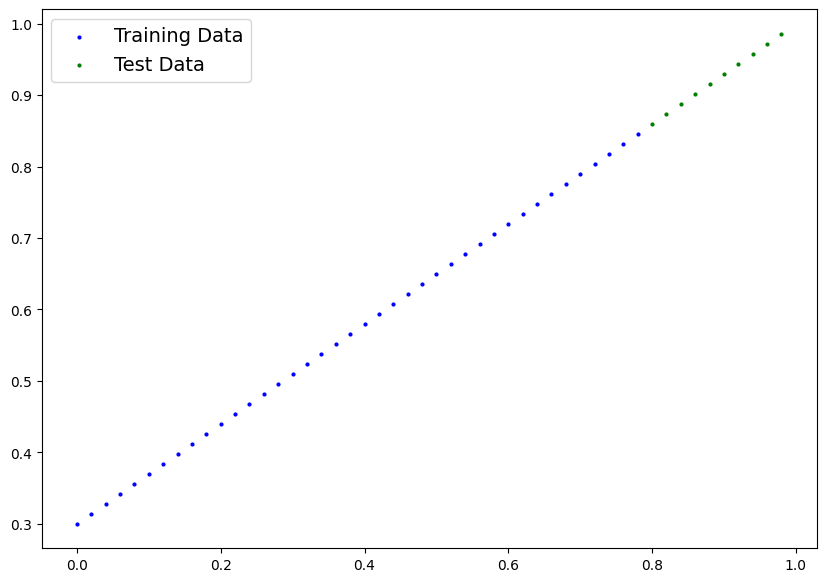

In [161]:
plot_predictions()

## 2. Building PyTorch Model
Essentially we will be creating LinearRegression Model

What our model does ?
* Start with random values (weight and bias)
* Look at training data and adjust the random values to better represent (or get closer to) the ideal value (the weight and bias values we used to create the data)

How does it do so ?

Through two main algorithms:
1. Gradient descent
2. Backpropagation

In [162]:
from torch import nn

class LinearRegressionModel(nn.Module):
  def __init__(self): #this initialises everytime LinearRegressionModel is called and self keep the changes into current running model only
    super().__init__() #initialises evrythng inside nn module
    #use nn.Linear()
    self.weight = nn.Parameter(torch.randn(1,
                                            requires_grad= True,
                                            dtype = torch.float))
    self.bias = nn.Parameter(torch.randn(1,
                                          requires_grad= True,
                                          dtype = torch.float))
    #Forward method to define the computation in the model
  def forward(self, x: torch.Tensor) -> torch.Tensor:
      return self.weight * x + self.bias #linear Regression execution


#### PyTorch Model Building essentials
Pytorch Cheat Sheet - https://pytorch-cn.com/tutorials/beginner/ptcheat.html


* torch.nn - contains all of the buildings for NN
* torch.nn.Parameter - what parameter should our try and learn, often a Pytorch layer from torch.nn will set these for use_deterministic_algorithms
* torch.nn.Module - The base class for all NN modules, if you subclass it, you should overwrite forward()
* torch.optim - this where the optimizer in PyTorch live, they will help with Gradient Descent
* def forward() - All nn module subclasses require you to overwrite forward(), this method defines what happens in forward computation

### Checking the content of our Pytorch model

We can check our model parameter using .parameters()

In [163]:
#Create a Random Seed
torch.manual_seed(42)

#Create an Instance of the model
model_0 = LinearRegressionModel()

#check out the Parameter
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [164]:
# List named Parameters

model_0.state_dict() # we need to adjust (get closer to) to defined parameter as known ones

OrderedDict([('weight', tensor([0.3367])), ('bias', tensor([0.1288]))])

### Making prdctions using torch.inference_mode()

To check out model predictive power, lets see how well it predicts 'y_test' based on "X_test"

In [165]:
X_test, y_test

(tensor([[0.8000],
         [0.8200],
         [0.8400],
         [0.8600],
         [0.8800],
         [0.9000],
         [0.9200],
         [0.9400],
         [0.9600],
         [0.9800]]),
 tensor([[0.8600],
         [0.8740],
         [0.8880],
         [0.9020],
         [0.9160],
         [0.9300],
         [0.9440],
         [0.9580],
         [0.9720],
         [0.9860]]))

In [166]:
with torch.inference_mode(): # we are using this than simply taking prdctions from model as bcs it does turns (disable) off the gradient tracking
  y_preds = model_0(X_test)

y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

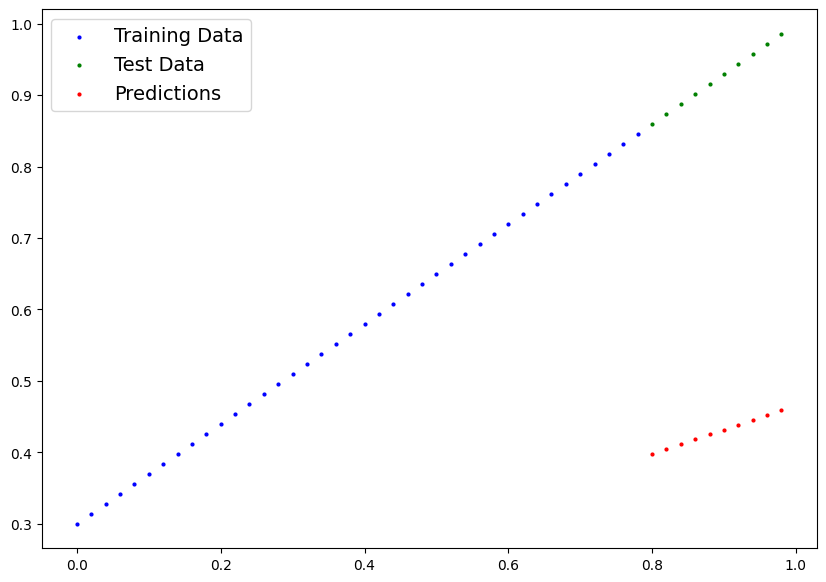

In [167]:
plot_predictions(predictions = y_preds)
# the predction are far bcs they are random parameters

# 3. Training Model

the whole idea here is to move model from some *unknown* paarmeters to some known parameters.

To measure how poor our model predction are is to use loss_functions()

Things we need to Train:

* *Loss Functions*: A function to measure how the difference is btw our predction and target value.
* *Optimizer* - Takes into account the loss of model and adjust the model params.  - has two things as "params and lr"


In [168]:
model_0.state_dict(), list(model_0.parameters())

(OrderedDict([('weight', tensor([0.3367])), ('bias', tensor([0.1288]))]),
 [Parameter containing:
  tensor([0.3367], requires_grad=True),
  Parameter containing:
  tensor([0.1288], requires_grad=True)])

In [169]:
 # we want to minimise the loss function and optimise it with parameters
 #nn.L1loss - which Mean Absolute Error, nn.MSEloss - mean squared error ( for regression problms) & nn.BCEloss - may be used for Classification problem

#Loss Function
loss_fn = nn.L1Loss()

#Optimizer - like SGD, Adam - they adjust our params to reduce the loss
optimizer = torch.optim.SGD(params = model_0.parameters(),
                            lr = 0.01) #lr is learning_rate is a hyperperameter- smaller the lr smaller the change in parameter by optimizer

### Build a Training Loop in pytorch

A couple of things we need in a training loop:
0. Loop Through the data
1. forward() pass - involves data moving through our model 'forward()' - to make prdction on data
2. Calculate the loss & compare forward pass prdction on ground level
3. Optimizer zero grad
4. Loss Backward - move backward through network to calculte the gradient of each parameter of our model wrt the loss
5. Optimizer step - use the optimizer to adjust our model params to try and imrpove the loss (*Gradient Descent*)

In [170]:
from numpy import test
random_seed=42
epochs = 200 # no. of loop through whole data

#Track the different values
epoch_count = []
loss_values = []
test_loss_values = []

#set the random seed
torch.manual_seed(random_seed)

for epochs in range(epochs):
  #set the model to training mode
  model_0.train() # sets all params that require gradient to require gradient

  #1. Forward pass
  y_preds = model_0(X_train)
  #2. Calculate the loss
  loss = loss_fn(y_preds, y_train)
  print("Loss", loss)
  #3. optimizer
  optimizer.zero_grad()
  #4. loss backward
  loss.backward()
  #5. optimizer step
  optimizer.step() #performs gradient descent - this accumulate through the loop...we have to zero them in step 3.

  #testing
  model_0.eval() #turn off gradient tracking and other setting not needed in evaluation
  with torch.inference_mode():
    # 1. Forward pass
    test_pred = model_0(X_test)

    #2. Calculate the loss
    test_loss = loss_fn(test_pred, y_test)

  if epochs % 10 == 0: # done to know what happening every 10 epoch with our model
    epoch_count.append(epochs)
    loss_values.append(loss)
    test_loss_values.append(test_loss)
    print(f"Epoch: {epochs} | Loss: {loss} | Test Loss: {test_loss}")
    print(model_0.state_dict())

Loss tensor(0.3129, grad_fn=<MeanBackward0>)
Epoch: 0 | Loss: 0.31288138031959534 | Test Loss: 0.48106518387794495
OrderedDict({'weight': tensor([0.3406]), 'bias': tensor([0.1388])})
Loss tensor(0.3014, grad_fn=<MeanBackward0>)
Loss tensor(0.2898, grad_fn=<MeanBackward0>)
Loss tensor(0.2783, grad_fn=<MeanBackward0>)
Loss tensor(0.2668, grad_fn=<MeanBackward0>)
Loss tensor(0.2553, grad_fn=<MeanBackward0>)
Loss tensor(0.2438, grad_fn=<MeanBackward0>)
Loss tensor(0.2322, grad_fn=<MeanBackward0>)
Loss tensor(0.2207, grad_fn=<MeanBackward0>)
Loss tensor(0.2092, grad_fn=<MeanBackward0>)
Loss tensor(0.1977, grad_fn=<MeanBackward0>)
Epoch: 10 | Loss: 0.1976713240146637 | Test Loss: 0.3463551998138428
OrderedDict({'weight': tensor([0.3796]), 'bias': tensor([0.2388])})
Loss tensor(0.1862, grad_fn=<MeanBackward0>)
Loss tensor(0.1746, grad_fn=<MeanBackward0>)
Loss tensor(0.1631, grad_fn=<MeanBackward0>)
Loss tensor(0.1516, grad_fn=<MeanBackward0>)
Loss tensor(0.1401, grad_fn=<MeanBackward0>)
Loss 

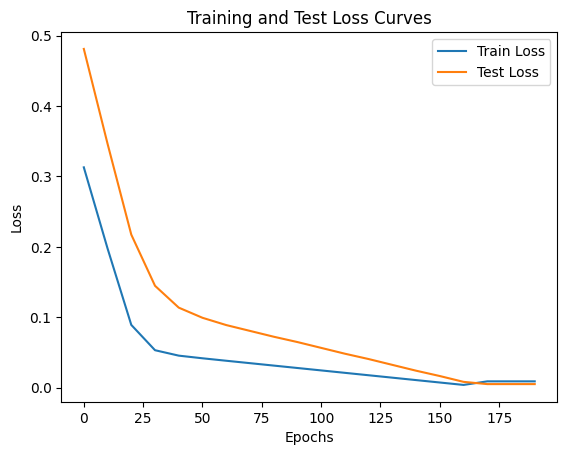

In [171]:
#plot the loss curves
import numpy as np
plt.plot(epoch_count, np.array(torch.tensor(loss_values).numpy()),label="Train Loss")
plt.plot(epoch_count, test_loss_values, label="Test Loss")
plt.title("Training and Test Loss Curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend()

In [172]:
with torch.inference_mode():
  y_preds_new = model_0(X_test)

In [173]:
weight, bias

(0.7, 0.3)

In [174]:
model_0.state_dict() #we would see that we have almost near the known values

OrderedDict([('weight', tensor([0.6990])), ('bias', tensor([0.3093]))])

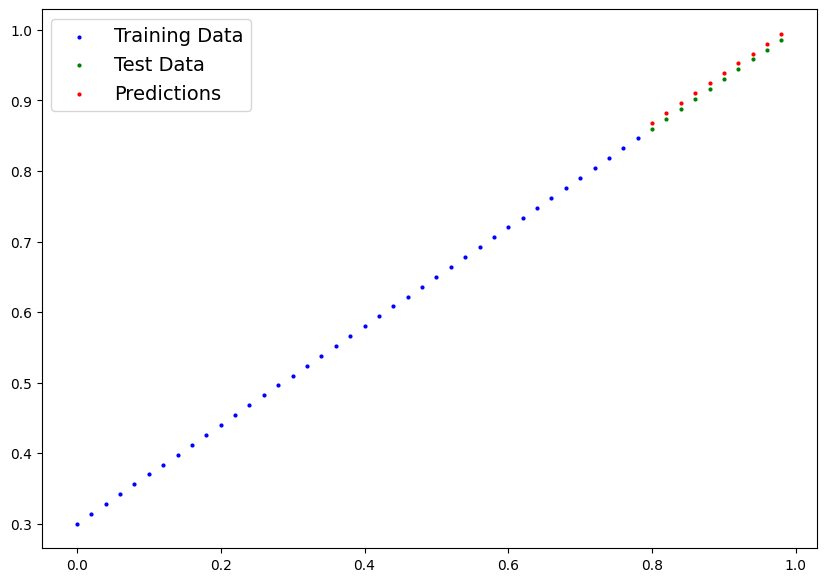

In [175]:
plot_predictions(predictions= y_preds_new)

## Saving the Model in PyTorch

There are 3 main methods for saving and loading models in PyTorch:

1. 'torch.save()' - allows you save a Pytorch object in Python pickle format
2. 'torch.load()' - allow you to load a saved model
3. 'torch.nn.Module.load_state_dict()' - allows you to load the parameters of a model


In [178]:
from pathlib import Path

#create model directory
MODEL_PATH =Path("Models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

#create model save path
MODEL_NAME = "01_pytorch_workflow_model.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

#Saving a Model with State_dict()
print(f"Saving Model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_0.state_dict(),
           f=MODEL_SAVE_PATH)

Saving Model to: Models/01_pytorch_workflow_model.pth


In [ ]:
#Loading the PyTorch Model
since we saved our model state_dict() rather than entire model, we will create instance of our model and

In [179]:
# To laod in a saved state_dict we have to instantiate a new instance of our model class
loaded_model_0 = LinearRegressionModel()

#Load the saved state_dict_of_model_0 (this will update the new instance with updated parameter)
loaded_model_0.load_state_dict(torch.load(f=MODEL_SAVE_PATH)) # f is file like object

<All keys matched successfully>

In [180]:
loaded_model_0.state_dict()

OrderedDict([('weight', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [183]:
#lets make some predictions with our loaded model

loaded_model_0.eval()
with torch.inference_mode():
  loaded_model_0_preds = loaded_model_0(X_test)

loaded_model_0_preds

tensor([[0.8685],
        [0.8825],
        [0.8965],
        [0.9105],
        [0.9245],
        [0.9384],
        [0.9524],
        [0.9664],
        [0.9804],
        [0.9944]])

In [184]:
#our made model predictions
model_0.eval()
with torch.inference_mode():
  y_preds = model_0(X_test)

y_preds


tensor([[0.8685],
        [0.8825],
        [0.8965],
        [0.9105],
        [0.9245],
        [0.9384],
        [0.9524],
        [0.9664],
        [0.9804],
        [0.9944]])

In [186]:
#lets check if both matches or not
y_preds == loaded_model_0_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])